In [ ]:
import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvi
import umap
from scvi.model.base._save_load import _load_saved_files

from human_gastruloid_analysis import *

sc.set_figure_params(figsize=(5, 5))

In [2]:
def strip_project_path(path: str):
    cwd = os.getcwd()
    return path[cwd.index("human-gastruloid-analysis") :]


cwd = os.getcwd()
print("Current working folder: " + strip_project_path(cwd))
data_dir = Path("../data")
model_dir = Path("../src/human_gastruloid_analysis/models")
print("Data folder: " + strip_project_path(str(data_dir.resolve())))
print("Model folder: " + strip_project_path(str(model_dir.resolve())))

Current working folder: human-gastruloid-analysis/notebooks
Data folder: human-gastruloid-analysis/data
Model folder: human-gastruloid-analysis/src/human_gastruloid_analysis/models


In [3]:
# unpublished data (not public)
# load in data and model
adata = sc.read_h5ad("./adata_plan1_heemskerk_liang_amanda_42-96h_hvg.h5ad")
model = model_dir / model_table["scvi_IH-gastruloid_d2-4_Liang-Amanda-Meso"]
model_config = _load_saved_files(str(model), load_adata=False, map_location="cpu")[0][
    "registry_"
]
model_input_genes = model_config["field_registries"]["X"]["state_registry"][
    "column_names"
]
model_cell_cycle_covariates = model_config["setup_args"]["continuous_covariate_keys"]
adata.obs[model_cell_cycle_covariates] = adata[
    :, model_cell_cycle_covariates
].X.toarray()
adata = adata[:, model_input_genes].copy()
model = scvi.model.SCVI.load(dir_path=model, adata=adata)

INFO     File                                                                                                      
         ../src/human_gastruloid_analysis/models/20260224_SCVI_plan1_heemskerk_liang_amanda_42-96h_750hvg_20260224-
         082215_lr1e-05_lv30_hd128_ly1_dr0.1_nb/model.pt already downloaded                                        
INFO     File                                                                                                      
         ../src/human_gastruloid_analysis/models/20260224_SCVI_plan1_heemskerk_liang_amanda_42-96h_750hvg_20260224-
         082215_lr1e-05_lv30_hd128_ly1_dr0.1_nb/model.pt already downloaded                                        


In [4]:
# extract latent coordinates and perform label transfer
adata.obsm["X_scvi"] = model.get_latent_representation()
# those functions are in src/human_gastruloid_analysis/knn.py
knn_transferer = weighted_knn_trainer(
    adata[~adata.obs["leiden_sub"].isna()], "X_scvi", n_neighbors=10
)
labels, _ = weighted_knn_transfer(
    adata,
    "X_scvi",
    adata[~adata.obs["leiden_sub"].isna()].obs,
    "leiden_sub",
    knn_transferer,
)
adata.obs["leiden_sub_knn"] = labels["leiden_sub"]

/home/stan/Git/human-gastruloid-analysis/.venv/lib/python3.13/site-packages/torch/utils/data/_utils/collate.py:70: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return torch.as_tensor(data)


Weighted KNN with n_neighbors = 10 ... finished!


In [106]:
# UMAP
gastruloid_data_subdir = data_dir / "IH-2025-nature-data"
meta = pd.read_csv(
    gastruloid_data_subdir / "MP_old_48-96h_new_D6-10_meta.csv", index_col=0
)
adata_sub = adata[adata.obs["sample_labels"].str.contains("48h-|72h-|96h-")]
ini_pos = np.array(adata_sub.obs.loc[:, ["umap_old_48-96h_x", "umap_old_48-96h_y"]])
mask = np.isnan(ini_pos)
keep = ~mask[:, 0] & ~mask[:, 1]
adata_sub = adata_sub[keep,]
ini_pos = np.array(adata_sub.obs.loc[:, ["umap_old_48-96h_x", "umap_old_48-96h_y"]])
trans = umap.UMAP(
    n_neighbors=10,
    min_dist=0.01,
    spread=1.0,
    n_components=2,
    init=ini_pos,
    local_connectivity=0.8,
    negative_sample_rate=2,
    random_state=4,
    n_epochs=70,
    a=4,
    b=0.825,
).fit(adata_sub.obsm["X_scvi"])
adata.obsm["X_umap"] = trans.transform(adata.obsm["X_scvi"])

/home/stan/Git/human-gastruloid-analysis/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [113]:
sample_to_stage = {
    "48h-1": "48h",
    "48h-2": "48h",
    "72h-1": "72h",
    "72h-2": "72h",
    "96h-1": "96h",
    "96h-2": "96h",
    "2020-FC-9000_42h": "42h",
    "BMP4_42h": "42h",
    "michigan-42h_Ctrl": "42h",
    "michigan-42h_shAPLNR": "42h",
    "michigan-72h_Ctrl": "72h",
    "michigan-72h_shAPLNR": "72h",
    "chicago-42h_Ctrl": "42h",
    "chicago-42h_shAPLNR": "42h",
    "chicago-72h_Ctrl": "72h",
    "chicago-72h_shAPLNR": "72h",
    "bc_2": "144h",
    "bc_3": "192h",
    "bc_4": "240h",
}
adata.obs["stage"] = adata.obs["sample_labels"].astype("str").replace(sample_to_stage)
stage_order = ["42h", "48h", "72h", "96h", "144h", "192h", "240h"]
adata.obs["stage"] = (
    adata.obs["stage"].astype("category").cat.set_categories(stage_order, ordered=True)
)
np.random.seed(1)
adata = adata[np.random.permutation(adata.shape[0]), :].copy()

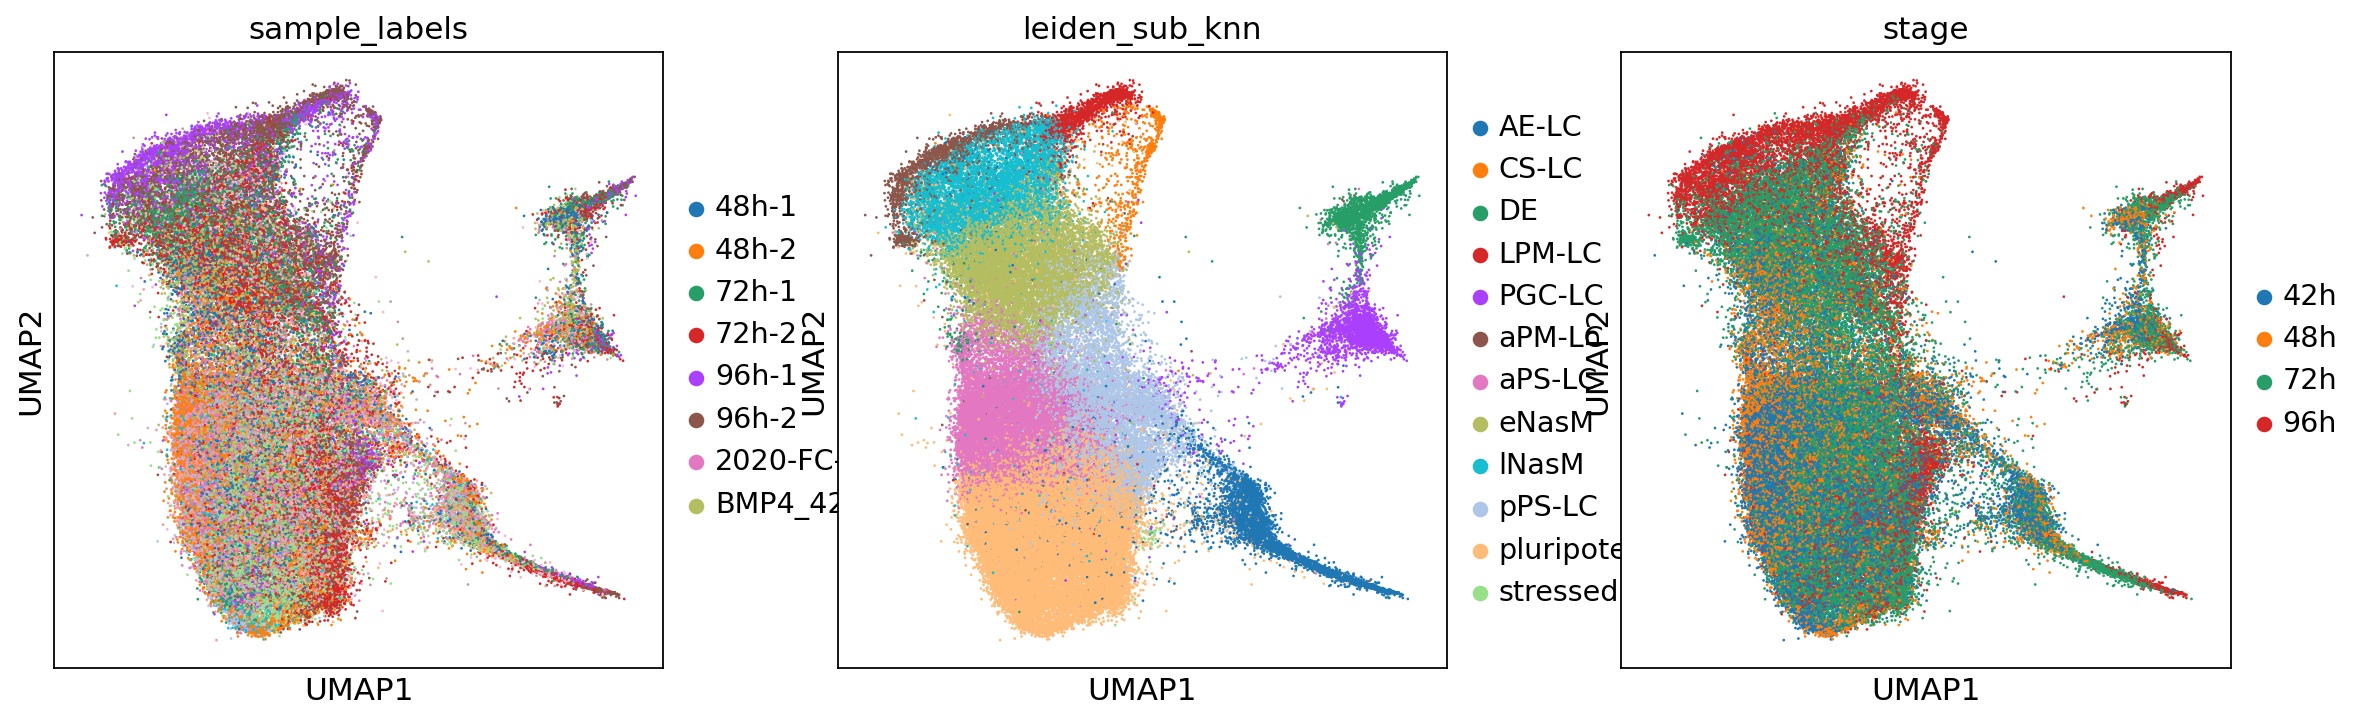

In [120]:
sc.pl.umap(adata, color=["sample_labels", "leiden_sub_knn", "stage"], s=6)

In [151]:
cell_types_exclude = ["LPM-LC", "CS-LC"]
adata_sub_new_ctrl = adata[
    np.logical_and(
        adata.obs["sample_labels"].str.contains(".*Ctrl"),
        adata.obs["stage"].str.contains("72h"),
    )
].copy()
adata_sub_new_sh = adata[
    np.logical_and(
        adata.obs["sample_labels"].str.contains(".*sh"),
        adata.obs["stage"].str.contains("72h"),
    )
].copy()

Almarkers = ["ALCAM", "MLLT3", "PITX1", "TBX4", "HOXA1", "CDX2"]
# ExMemarkers = [g for g in adata_all_cc.raw.var_names if g.split()[0] in ['LUM','COL6A1','CALU','SPARC']]; #'POSTN',
LPMmarkers = ["NKX2-5", "MYL4", "MYL7", "FOXF1", "TMEM88", "HAND1"]
# pharmarkers = [g for g in adata_all_cc.raw.var_names if g.split()[0] in ['ID4','ID1','ISL1']]
somitomere = ["MESP1", "MESP2", "RIPPLY2"]  # 'HES7','EVX1'
somite = ["FOXC2", "MEOX1"]  # ,'TCF15'
PMmarkers = ["MSGN1", "EVX1", "RSPO3", "TBX6", "FOXC1"]  #'MIXL1','FOXC1','DLL3',

plurimarkers = ["NANOG", "SOX2", "USP44"]
apsmarkers = ["EOMES", "MIXL1"]
ppsmarkers = ["WNT8A", "TBXT"]  # CDX2
ammarkers = ["GABRP", "WNT6", "ISL1"]
DEmarkers = ["FOXA2", "HNF1B"]
PGCmarkers = ["SOX17", "PRDM1", "NANOS3", "TFAP2C"]
stressedmarkers = ["DDIT3", "HRK"]
marker_genes_dict = {
    "PM": PMmarkers,
    "somitomere": somitomere,
    "somite": somite,
    # "LPM": LPMmarkers,
    # "Al": Almarkers,  # subclusterlabels[9]:ExMemarkers,
    "PPS": ppsmarkers,
    "APS": apsmarkers,
    "DE": DEmarkers,
    "PGCLC": PGCmarkers,
    # "pluri": plurimarkers,
    "AE-LC": ammarkers,
}  # 'stressed':stressedmarkers

order = [
    "eNasM",
    "lNasM",
    "aPM-LC",
    "pPS-LC",
    "aPS-LC",
    "DE",
    "PGC-LC",
    "pluripotent",
    "AE-LC",
]
allmarkers = []
for key in marker_genes_dict:
    allmarkers = allmarkers + marker_genes_dict[key]
var_group_labels = list(marker_genes_dict.keys())
var_group_positions = []
idx = 0
for key in marker_genes_dict:
    n = sum(
        1
        for g in marker_genes_dict[key]
        for q in adata_sub_new_ctrl.raw.var_names
        if q.split()[0] == g
    )
    if n > 0:
        var_group_positions.append((idx, idx + n - 1))
        idx += n
    else:
        var_group_labels.remove(key)
allmarkersp = []
for g in allmarkers:
    allmarkersp = allmarkersp + [
        q for q in adata_sub_new_ctrl.raw.var_names if q.split()[0] == g
    ]
var_group_labels = [
    "somitomere\n" if l == "somitomere" else l for l in var_group_labels
]
var_group_labels = ["PPS\n" if l == "PPS" else l for l in var_group_labels]

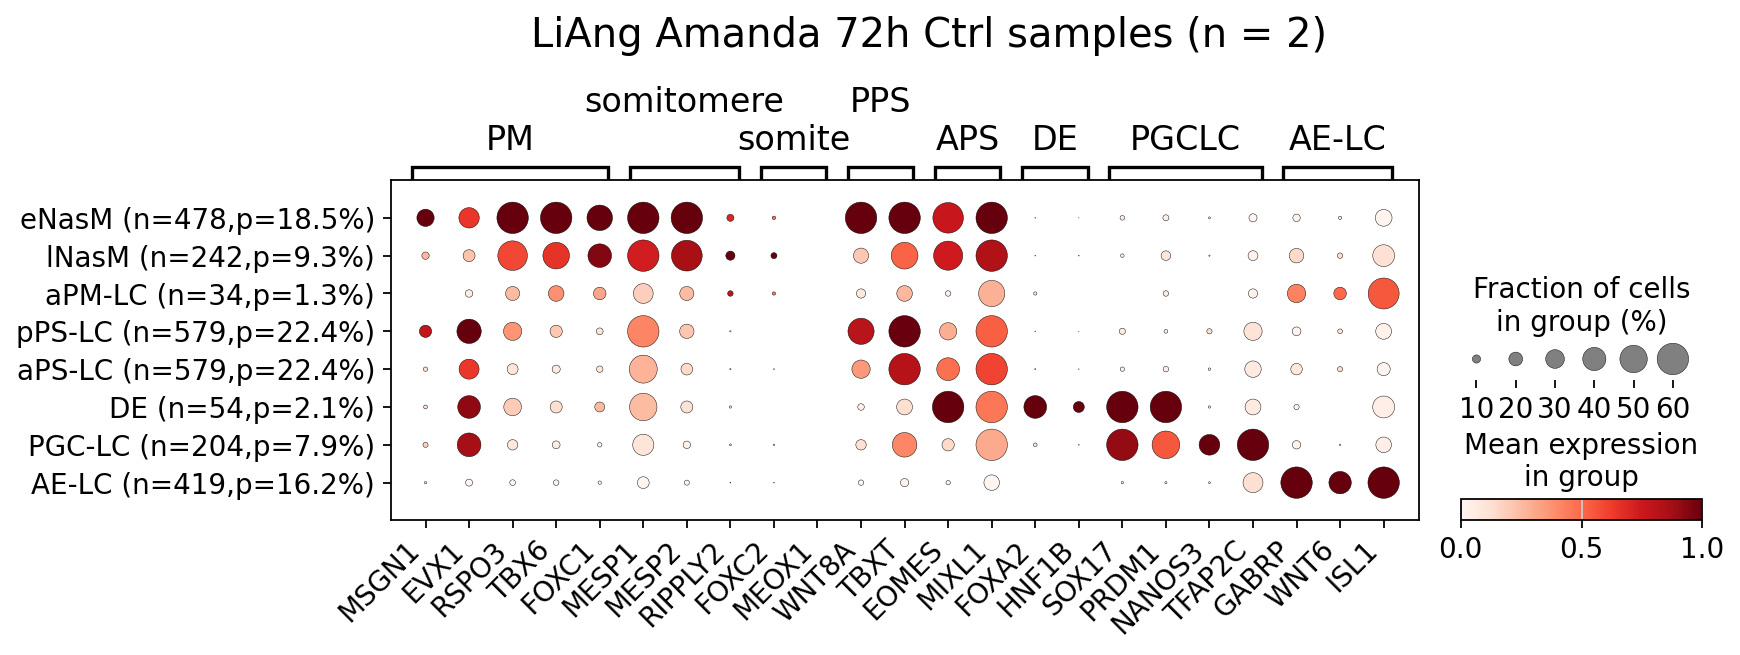

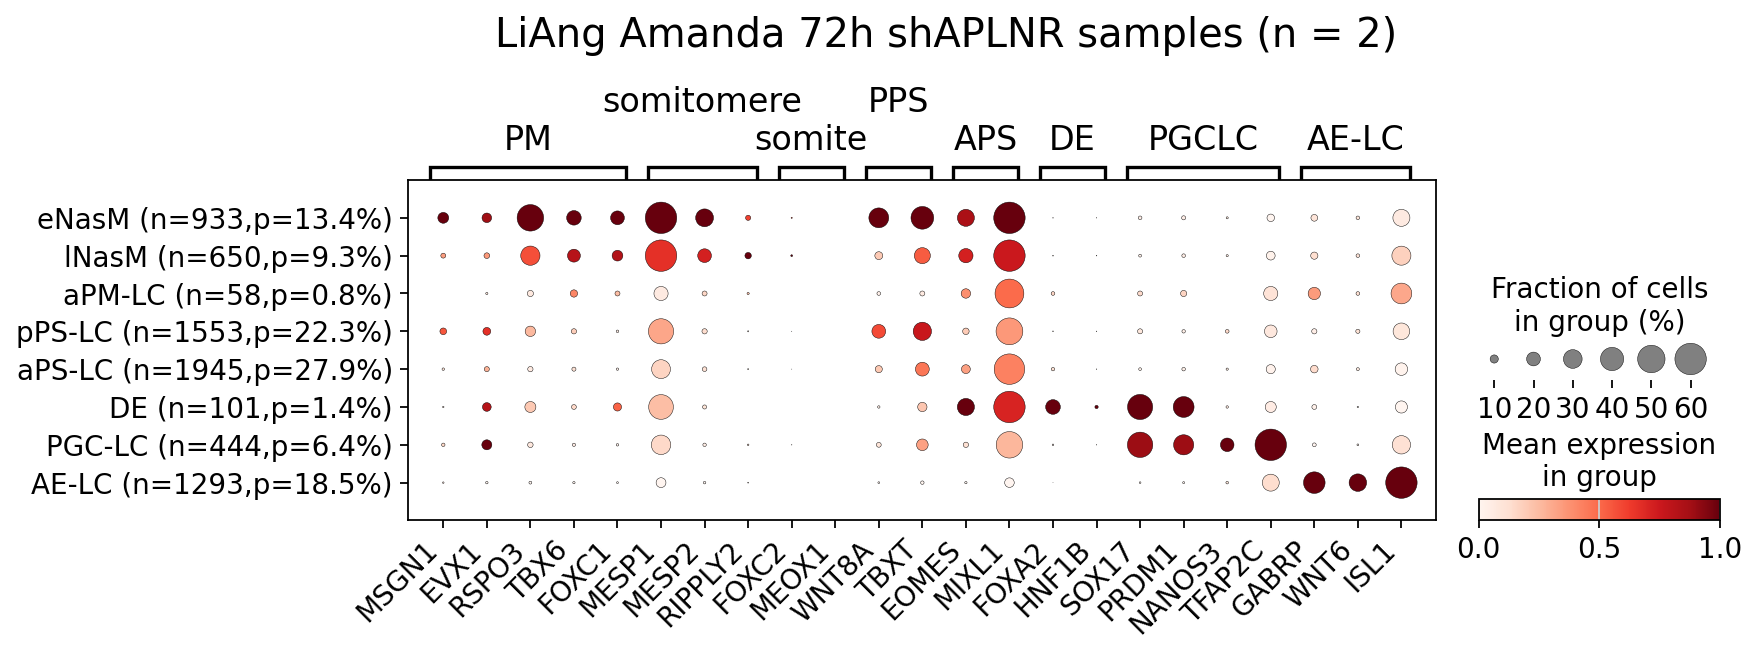

In [154]:
mpl.rcdefaults()
sc.set_figure_params(figsize=(15, 5), fontsize=15)

adata_nostress = adata_sub_new_ctrl[
    ~adata_sub_new_ctrl.obs["leiden_sub_knn"].str.contains("stressed|pluri")
].copy()
adata_nostress = adata_nostress[adata_nostress.obs["leiden_sub_knn"].isin(order)].copy()
adata_nostress.obs["leiden_sub_knn"] = adata_nostress.obs[
    "leiden_sub_knn"
].cat.remove_unused_categories()
counts = adata_nostress.obs["leiden_sub_knn"].value_counts()
keep = counts[counts >= 10].index
adata_nostress = adata_nostress[adata_nostress.obs["leiden_sub_knn"].isin(keep)].copy()
cell_number = adata_nostress.obs["leiden_sub_knn"].value_counts().to_dict()
cell_number_total = sum(cell_number.values())
ax_dict = sc.pl.dotplot(
    adata_nostress,
    allmarkersp,
    categories_order=[
        o for o in order if o in adata_nostress.obs["leiden_sub_knn"].cat.categories
    ],
    groupby="leiden_sub_knn",
    dendrogram=False,
    show=False,
    standard_scale="var",
    var_group_rotation=0,
    var_group_labels=var_group_labels,
    var_group_positions=var_group_positions,
    dot_max=0.6,
)
ax_dict["mainplot_ax"].set_xticklabels(
    [g.get_text().split()[0] for g in ax_dict["mainplot_ax"].get_xticklabels()]
)
plt.setp(ax_dict["mainplot_ax"].get_xticklabels(), rotation=45, ha="right")
ax_dict["mainplot_ax"].set_yticklabels(
    [
        f"{g.get_text()} (n={cell_number[g.get_text()]},p={np.round(cell_number[g.get_text()] / cell_number_total * 100, 1)}%)"
        for g in ax_dict["mainplot_ax"].get_yticklabels()
    ]
)
plt.suptitle("LiAng Amanda 72h Ctrl samples (n = 2)")

adata_nostress = adata_sub_new_sh[
    ~adata_sub_new_sh.obs["leiden_sub_knn"].str.contains("stressed|pluri")
].copy()
adata_nostress = adata_nostress[adata_nostress.obs["leiden_sub_knn"].isin(order)].copy()
adata_nostress.obs["leiden_sub_knn"] = adata_nostress.obs[
    "leiden_sub_knn"
].cat.remove_unused_categories()
counts = adata_nostress.obs["leiden_sub_knn"].value_counts()
keep = counts[counts >= 10].index
adata_nostress = adata_nostress[adata_nostress.obs["leiden_sub_knn"].isin(keep)].copy()
cell_number = adata_nostress.obs["leiden_sub_knn"].value_counts().to_dict()
cell_number_total = sum(cell_number.values())
ax_dict = sc.pl.dotplot(
    adata_nostress,
    allmarkersp,
    categories_order=[
        o for o in order if o in adata_nostress.obs["leiden_sub_knn"].cat.categories
    ],
    groupby="leiden_sub_knn",
    dendrogram=False,
    show=False,
    standard_scale="var",
    var_group_rotation=0,
    var_group_labels=var_group_labels,
    var_group_positions=var_group_positions,
    dot_max=0.6,
)
ax_dict["mainplot_ax"].set_xticklabels(
    [g.get_text().split()[0] for g in ax_dict["mainplot_ax"].get_xticklabels()]
)
plt.setp(ax_dict["mainplot_ax"].get_xticklabels(), rotation=45, ha="right")
ax_dict["mainplot_ax"].set_yticklabels(
    [
        f"{g.get_text()} (n={cell_number[g.get_text()]},p={np.round(cell_number[g.get_text()] / cell_number_total * 100, 1)}%)"
        for g in ax_dict["mainplot_ax"].get_yticklabels()
    ]
)
plt.suptitle("LiAng Amanda 72h shAPLNR samples (n = 2)")

del adata_nostress